In [56]:
import numpy as np
import pandas as pd
from pathlib import Path
import re

import matplotlib.pyplot as plt


In [15]:
ROOT = Path.cwd().parent
DATA_PATH = ROOT / 'data'

DATA_PATH



PosixPath('/Users/romacarapetean/Desktop/Projects/University/MLPC2026/data')

#### a 

In [16]:
npz_path = DATA_PATH / 'audio_features' / '000078.npz'

# Extract a single npz file and print its contents
with np.load(npz_path, allow_pickle=True) as data:
    print(f"File: {npz_path.name}")
    print(f"Keys ({len(data.files)}): {data.files}\n")
    for key in data.files:
        value = data[key]
        print(f"{key}:")
        print(f"  shape={value.shape}, dtype={value.dtype}")
        if value.size <= 10:
            print(f"  values={value}")
        else:
            flat = value.ravel()
            print(f"  first 10 values={flat[:10]}")
        print()

File: 000078.npz
Keys (68): ['zcr_mean', 'zcr_std', 'zcr_min', 'zcr_max', 'start_time', 'end_time', 'melspect_mean', 'melspect_std', 'melspect_min', 'melspect_max', 'mfcc_mean', 'mfcc_std', 'mfcc_min', 'mfcc_max', 'mfcc_d_mean', 'mfcc_d_std', 'mfcc_d_min', 'mfcc_d_max', 'mfcc_d2_mean', 'mfcc_d2_std', 'mfcc_d2_min', 'mfcc_d2_max', 'flux_mean', 'flux_std', 'flux_min', 'flux_max', 'flatness_mean', 'flatness_std', 'flatness_min', 'flatness_max', 'centroid_mean', 'centroid_std', 'centroid_min', 'centroid_max', 'bandwidth_mean', 'bandwidth_std', 'bandwidth_min', 'bandwidth_max', 'contrast_mean', 'contrast_std', 'contrast_min', 'contrast_max', 'rolloff_low_mean', 'rolloff_low_std', 'rolloff_low_min', 'rolloff_low_max', 'rolloff_high_mean', 'rolloff_high_std', 'rolloff_high_min', 'rolloff_high_max', 'energy_mean', 'energy_std', 'energy_min', 'energy_max', 'power_mean', 'power_std', 'power_min', 'power_max', 'annotations', 'is_own_recording', 'class_names', 'annotator_ids', 'target_classes', 'n

## Get annotations df

In [17]:
annotation_path = DATA_PATH / 'annotations.csv'

annotations = pd.read_csv(annotation_path)
annotations_df = pd.DataFrame(annotations)
print(annotations_df.shape)
annotations_df

(37419, 6)


,filename,annotator_id,annotation,onset,offset,is_own_recording
0,000112.wav,2190518039615423109192646528977018723001939610...,footsteps,13.060211,13.315831,False
1,000695.wav,4496809211053681637690999252976315563042618669...,door_open_close,1.508440,2.061877,False
2,000488.wav,7535443191697509271271535104115945129183028445...,microwave,4.833705,25.929958,True
3,005087.wav,4496809211053681637690999252976315563042618669...,keyboard_typing,0.337356,18.230374,False
4,005465.wav,7618427328765435143030208879017391647684958822...,running_water,5.254437,15.088430,True
...,...,...,...,...,...,...
37414,002563.wav,1056540257956800261786298315033683341781057497...,footsteps,6.238223,9.636138,False
37415,000900.wav,3428425151602744749350825311836188628623960584...,vacuum_cleaner,0.560504,15.059245,False
37416,001732.wav,9931757987855761757854106089782104284187009332...,cutlery_dishes,4.500258,5.505797,True
37417,000148.wav,3778467525540798090940025888028004362004827851...,window_open_close,16.389992,18.286428,True


# Get metadata df

In [47]:
metadata_path = DATA_PATH / 'metadata.csv'

metadata = pd.read_csv(metadata_path)
metadata_df = pd.DataFrame(metadata)
print(metadata_df.shape)
metadata_df.head()


(3656, 9)


,filename,target_classes,recording_device,device_placement,recording_environment,scene_description,license,collector_id,non_target_classes
0,003075.wav,keyboard_typing;keychain,IPhone Xr,static,office,I was working on my laptop and playing with ke...,CC0 (Public Domain Dedication),04d6c4738cd1814c,fan_working;hand_moving_on_table
1,001117.wav,footsteps,Iphone 15 Pro,mobile,office,"I was walking and recorded a bird singing, car...",CC0 (Public Domain Dedication),f125c6e647565367,bird_sing;car
2,001982.wav,footsteps;door_open_close;cutlery_dishes,Surface Pro 8,static,living_room,I went to the patio door and opened it. I went...,CC0 (Public Domain Dedication),23f33a22e31d3072,NaN
3,003018.wav,footsteps;toilet_flushing;running_water,IPhone 15 Pro Max,static,bathroom,I flushed the toilet and walked to the sink. I...,CC0 (Public Domain Dedication),0ada14bcb30cabc5,towel_rustling;coughing;toilet_tank_refilling
4,002291.wav,light_switch;footsteps,Iphone 15 pro,mobile,bedroom;kitchen;bathroom,I turn on light switches around rooms while wa...,CC0 (Public Domain Dedication),9141efc68a18c882,NaN


### Part A

Metadata: Check the distribution of recording properties (e.g., placement, recording device types
and recording locations). You can either collect the values from the feature files or directly use the
metadata.csv.

Expected Answer: Explain which property you looked into. Provide statistics or a visualization and
a short interpretation.

## Recording device

In [ ]:
print(metadata_df['recording_device'])


0               IPhone Xr
1           Iphone 15 Pro
2           Surface Pro 8
3       IPhone 15 Pro Max
4           Iphone 15 pro
              ...        
3651        iphone 16 Pro
3652           smartphone
3653            iPhone 13
3654        iPhone 15 Pro
3655        iPhone 16 Pro
Name: recording_device, Length: 3656, dtype: str


#### This code snippet cleans and standardizes the 'recording_device' column in metadata_df to merge similar device names 

like Iphone pro 16 == iPhone 16 PRO

In [ ]:
def clean_device(s):
    s = str(s).lower().strip()
    s = re.sub(r"[_\-]+", " ", s)
    s = re.sub(r"\s+", " ", s)
    return s

def device_key(s):
    return " ".join(sorted(clean_device(s).split()))

metadata_df = metadata_df.copy()

metadata_df["recording_device_clean"] = metadata_df["recording_device"].apply(clean_device)
metadata_df["recording_device_key"] = metadata_df["recording_device"].apply(device_key)

canonical_map = (
    metadata_df.groupby("recording_device_key")["recording_device_clean"]
    .agg(lambda x: x.value_counts().idxmax())
    .to_dict()
)

metadata_df["recording_device"] = metadata_df["recording_device_key"].map(canonical_map)

metadata_df = metadata_df.drop(columns=['recording_device_clean', 'recording_device_key', 'recording_device_canonical'])
device_counts = metadata_df["recording_device"].value_counts().head(20)

print(device_counts)

recording_device
iphone 15             236
iphone 15 pro         137
iphone 13             132
iphone 14 pro         111
iphone 16              87
iphone 16 pro max      83
iphone                 83
iphone 14              78
iphone 12              76
iphone 16 pro          74
iphone 15 pro max      72
samsung galaxy a54     63
iphone 13 pro          61
iphone 17 pro          60
iphone 12 pro          50
samsung galaxy s21     46
iphone 17              42
smartphone             42
iphone 14 pro max      38
iphone 11              37
Name: count, dtype: int64


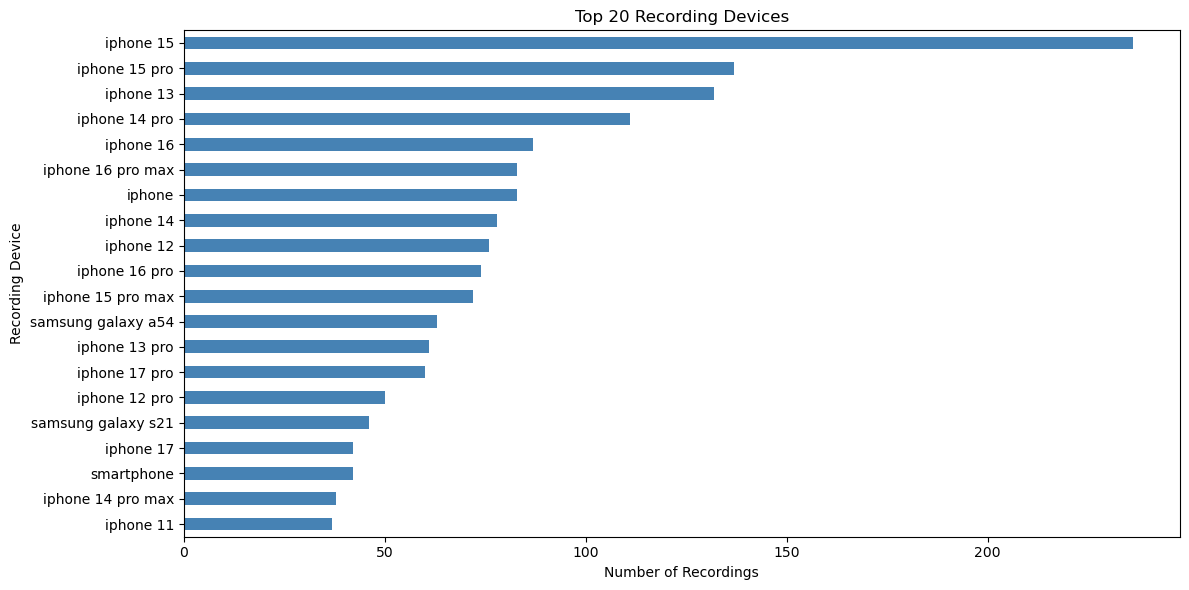

In [57]:
top_n = 20

plt.figure(figsize=(12, 6))
device_counts.head(top_n).sort_values().plot(kind="barh", color="steelblue")

plt.title(f"Top {top_n} Recording Devices")
plt.xlabel("Number of Recordings")
plt.ylabel("Recording Device")
plt.tight_layout()
plt.show()


## Device placement

In [60]:
placements = metadata_df['device_placement'].describe()
placements

count       3656
unique         2
top       static
freq        1970
Name: device_placement, dtype: object

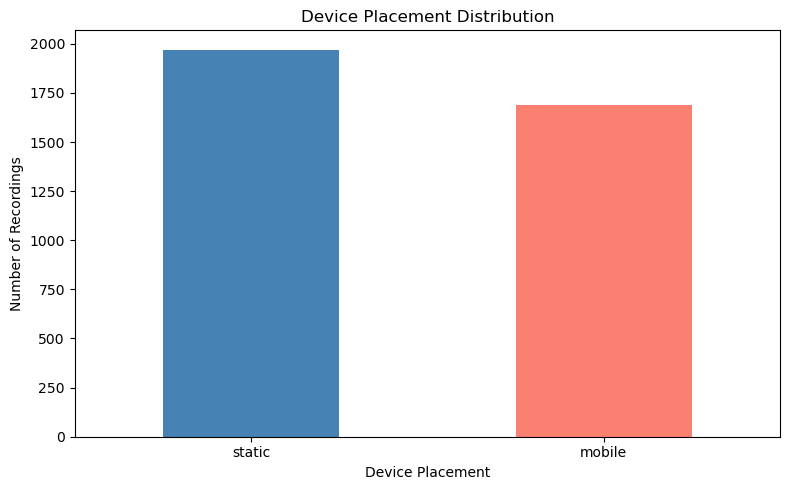

In [63]:
placement_counts = metadata_df["device_placement"].value_counts()

plt.figure(figsize=(8, 5))
placement_counts.plot(kind="bar", color=["steelblue", "salmon"])

plt.title("Device Placement Distribution")
plt.xlabel("Device Placement")
plt.ylabel("Number of Recordings")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


In [ ]:
placement_counts = metadata_df["device_placement"].value_counts()

static_count = placement_counts["static"]
mobile_count = placement_counts["mobile"]

difference = static_count - mobile_count
percent_more = (difference / mobile_count) * 100

print(f"Static count: {static_count}")
print(f"Mobile count: {mobile_count}")
print(f"Difference: {difference}")
print(f"Static is {percent_more:.2f}% more frequent than mobile")


Static count: 1970
Mobile count: 1686
Difference: 284
Static is 16.84% more frequent than mobile


So we see that the static position was used more frequently then the mobile one, to be precise by 16.84% or 284

## Recordig Environment

In [83]:
env_counts = (
    metadata_df["recording_environment"]
    .str.lower()
    .str.split(";")
    .explode()
    .str.strip()
    .value_counts()
)

print('After extracting locations out of combos')
print(env_counts)


After extracting locations out of combos
recording_environment
kitchen                   1070
bedroom                    711
hallway                    682
living_room                557
office                     430
bathroom                   364
toilet                     199
room                        20
home                         8
outside                      5
livingroom                   4
apartment                    3
laboratory                   3
dorm_room                    3
entrance                     3
stairwell                    2
lobby                        2
house_entrance               2
dorm_hallway                 2
home_entryway                2
staircase                    2
cafeteria                    2
dining_room                  2
nature                       2
studyroom                    1
apartment_hallway            1
cellar                       1
laundry_room                 1
storage_room                 1
cloak_room                   1
garage 

This code snippet cleans and standardizes the 'recording_env' column in metadata_df to merge similar recording places 

Like hallway;kitchen and kitchen;hallway 

In [ ]:

def normalize_environment_combo(s):
    parts = str(s).lower().strip().split(";")
    parts = [re.sub(r"\s+", " ", p.strip()) for p in parts]   # clean spaces
    parts = sorted(parts)                                     # sort labels
    return ";".join(parts)

metadata_copy = metadata_df.copy()

metadata_df["recording_environment"] = (
    metadata_copy["recording_environment"].apply(normalize_environment_combo)
)

combo_counts = metadata_df["recording_environment"].value_counts()

print(combo_counts.head(20))



recording_environment
kitchen                    962
bedroom                    585
living_room                424
hallway                    403
office                     397
bathroom                   268
toilet                     123
bedroom;hallway             62
hallway;living_room         62
bathroom;hallway            36
hallway;kitchen             33
hallway;toilet              33
kitchen;living_room         31
bathroom;toilet             20
room                        19
bedroom;living_room         18
bedroom;kitchen             15
hallway;office              11
kitchen;office               8
bathroom;hallway;toilet      8
Name: count, dtype: int64


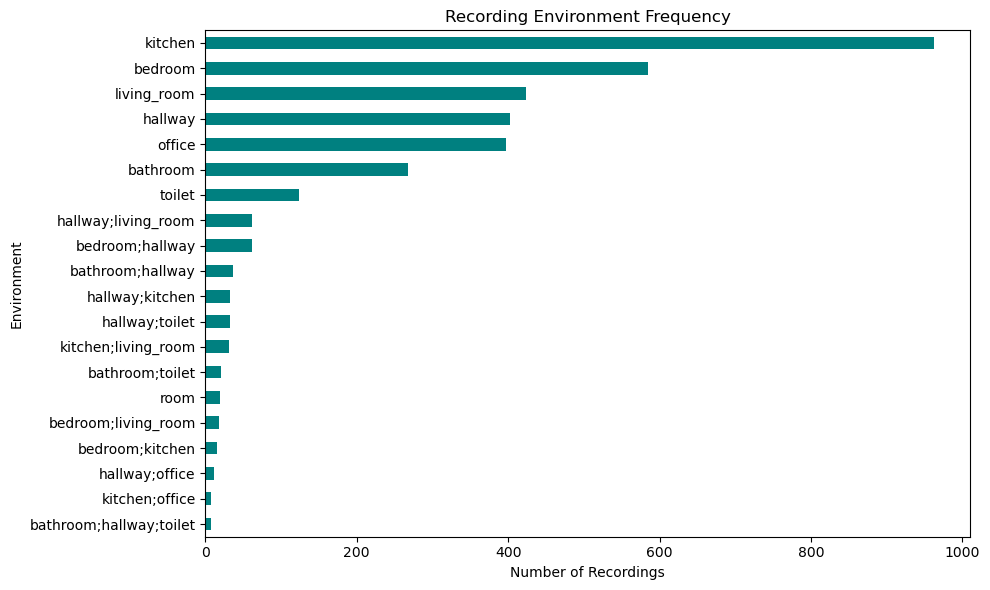

In [88]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
combo_counts.head(20).sort_values().plot(kind="barh", color="teal")

plt.title("Recording Environment Frequency")
plt.xlabel("Number of Recordings")
plt.ylabel("Environment")
plt.tight_layout()
plt.show()



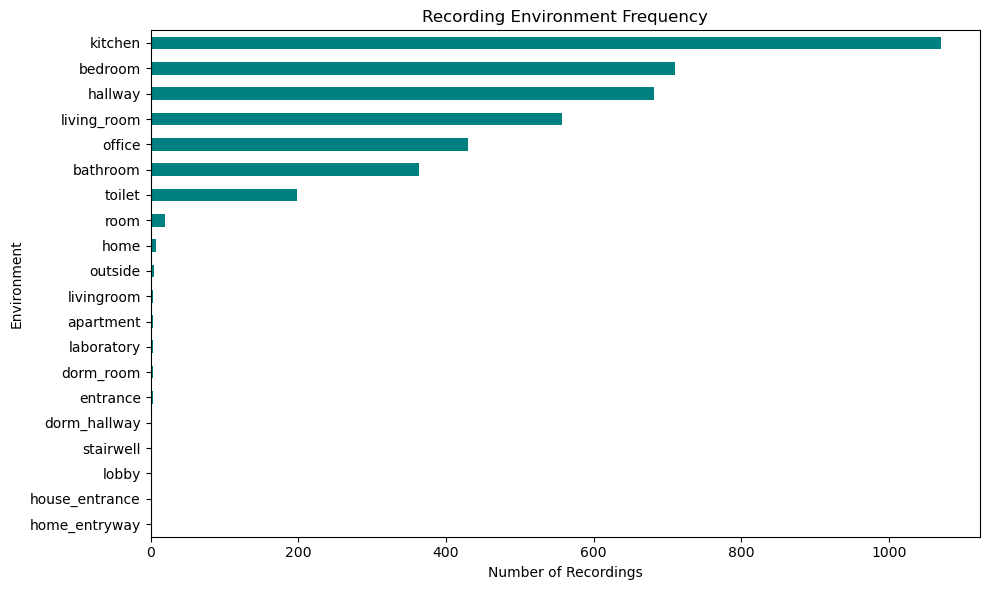

In [ ]:


plt.figure(figsize=(10, 6))
env_counts.head(20).sort_values().plot(kind="barh", color="teal")

plt.title("Recording Environment Frequency")
plt.xlabel("Number of Recordings")
plt.ylabel("Environment")
plt.tight_layout()
plt.show()
